## Data Exploration / Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load dataset

df = pd.read_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/raw data/synthetic_fraud_dataset.csv')

In [2]:

df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [4]:
for column in df.columns:
    if df[column].dtypes == 'O':
        print(f"\n\n\nColumn {column} \n {df[column].value_counts()}")




Column transaction_type 
 transaction_type
POS       2568
ATM       2529
QR        2506
Online    2397
Name: count, dtype: int64



Column merchant_category 
 merchant_category
Food           2023
Travel         2015
Electronics    2007
Clothing       1982
Grocery        1973
Name: count, dtype: int64



Column country 
 country
US    2050
FR    2027
UK    1965
DE    1930
TR    1928
NG     100
Name: count, dtype: int64


In [5]:
df['hour'].value_counts()

hour
13    584
17    564
6     560
10    560
21    560
16    555
15    553
20    548
7     545
12    541
9     541
23    539
19    539
18    536
11    534
8     530
14    522
22    496
4     117
3      18
0      16
2      16
5      15
1      11
Name: count, dtype: int64

### Transform the hour to cyclic codification

The hours of the day are not linear, they are cyclical. 23 and midnight are very close, but numerically they seem very far apart.

In [6]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


In [7]:
df

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud,hour_sin,hour_cos
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1,1.224647e-16,-1.000000
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0,-7.071068e-01,0.707107
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0,-5.000000e-01,-0.866025
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0,-2.588190e-01,0.965926
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0,-8.660254e-01,-0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1076,482,58.366442,POS,Clothing,DE,12,0.066366,0.086344,0,1.224647e-16,-1.000000
9996,4995,904,139.502160,POS,Travel,DE,13,0.119014,0.285680,0,-2.588190e-01,-0.965926
9997,3485,527,71.012122,Online,Travel,TR,8,0.119204,0.262262,0,8.660254e-01,-0.500000
9998,7922,771,21.031405,QR,Grocery,UK,12,0.027088,0.295243,0,1.224647e-16,-1.000000


### Clean outliers

In [8]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud,hour_sin,hour_cos
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000,-0.165774,-0.228579
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956,0.709368,0.645879
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000,-1.000000,-1.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000,-0.866025,-0.866025
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000,-0.258819,-0.258819
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000,0.500000,0.258819
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000,1.000000,1.000000


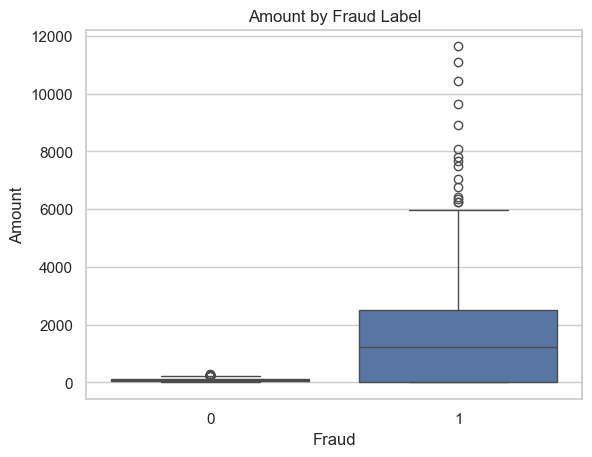

In [9]:
sns.set(style='whitegrid')
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.xlabel('Fraud')
plt.ylabel('Amount')
plt.title('Amount by Fraud Label')
plt.show()

In [10]:
df_outlier = df.copy()

Q1 = df_outlier['amount'].quantile(0.25)
Q3 = df_outlier['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outliers en general
outliers_fulldf = df_outlier[(df_outlier['amount'] < lower_bound) | (df_outlier['amount'] > upper_bound)]

outliers_fulldf

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud,hour_sin,hour_cos
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1,1.224647e-16,-1.000000
23,9933,121,4284.177967,ATM,Food,TR,12,0.737854,0.731071,1,1.224647e-16,-1.000000
84,9637,560,1148.378114,POS,Travel,DE,19,0.945709,0.835616,1,-9.659258e-01,0.258819
87,9711,935,952.547905,QR,Travel,UK,20,0.783611,0.985521,1,-8.660254e-01,0.500000
89,9939,291,2865.421641,ATM,Food,TR,13,0.834843,0.904304,1,-2.588190e-01,-0.965926
...,...,...,...,...,...,...,...,...,...,...,...,...
9711,9505,795,461.937955,QR,Food,NG,23,0.816233,0.781520,1,-2.588190e-01,0.965926
9787,9762,217,1455.533469,QR,Food,TR,4,0.893687,0.957413,1,8.660254e-01,0.500000
9794,9634,185,2231.990705,QR,Clothing,UK,7,0.750121,0.727340,1,9.659258e-01,-0.258819
9856,9947,123,1381.201430,POS,Food,US,19,0.940389,0.818065,1,-9.659258e-01,0.258819


In [11]:
df['is_fraud'].value_counts()

is_fraud
0    9500
1     500
Name: count, dtype: int64

In [12]:
# IQR method to detect outliers in the amount column
df_isoutlier = df.copy()

Q1 = df_isoutlier['amount'].quantile(0.25)
Q3 = df_isoutlier['amount'].quantile(0.75)
IQR = Q3 - Q1

# Limits for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_isoutlier['is_outlier'] = (df_isoutlier['amount'] < lower_bound) | (df_isoutlier['amount'] > upper_bound)

# Outliers by class
outliers_by_class = df_isoutlier.groupby('is_fraud')['is_outlier'].sum()

outliers_by_class

is_fraud
0     13
1    351
Name: is_outlier, dtype: int64

In the analysis of the amount variable, we observe that out of the 500 transactions classified as fraud, 351 contain outlier values. This suggests that fraudulent transactions are often associated with unusually high amounts.

Removing these outliers would significantly reduce the amount of information available to the model, potentially limiting its ability to detect meaningful patterns related to fraud. Therefore, the outliers in the amount column will not be removed, as they represent valuable information for the task.

Instead, a new feature will be created to capture the outlier severity using the z-score, allowing the model to leverage this information without discarding important data.

In [13]:
#Save cleaned dataset
df.to_csv('/Users/olgabencomo/Desktop/Proyectos Portafolio/Fraud Detection/data/processed/cleaned_dataset.csv',index=False)

### Amount Transactions Exploration

/var/folders/wt/k04sj_gj2txbf9dld5w6kv840000gn/T/ipykernel_99116/283461958.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


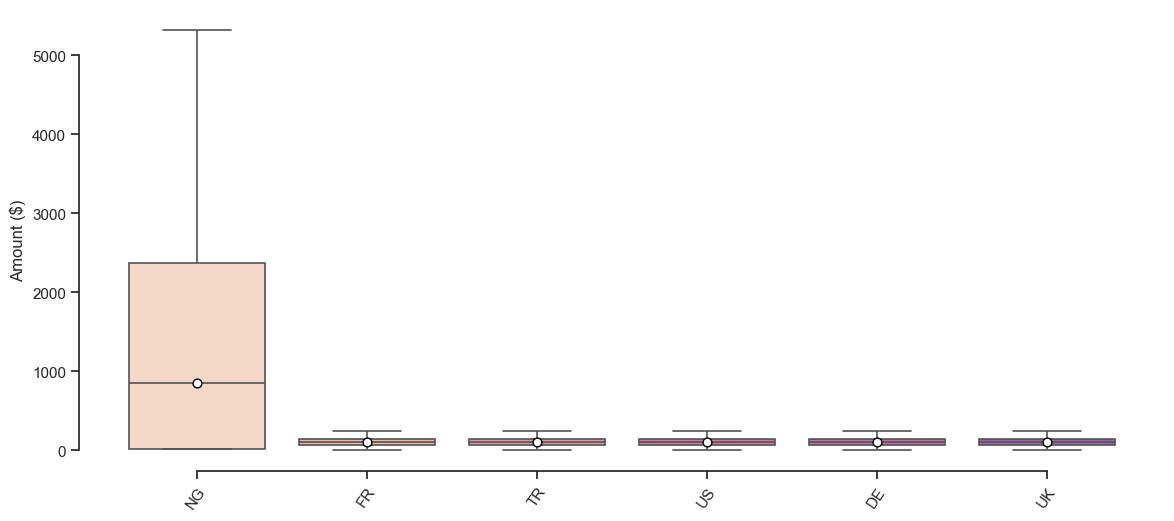

In [14]:

import colorsys
sns.set_theme(style="whitegrid")           

# Boxplot of amount transactions, ordered by median amount per country

countries = df["country"].value_counts().head(30).index.tolist()
df_country    = df[df["country"].isin(countries)]
country_order = (
    df_country.groupby("country")["amount"]
           .median()
           .sort_values(ascending=False)
           .index
)

base = sns.color_palette("rocket_r", len(country_order))

def lighten(color, amt=.4):
    h, l, s = colorsys.rgb_to_hls(*color)
    return colorsys.hls_to_rgb(h, min(1, l + amt*(1-l)), s)

palette = [
    lighten(c, .45) if i >= len(base) - 8 else c
    for i, c in enumerate(base)
]

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    x="country", y="amount", data=df_country,
    order=country_order, palette=palette,
    showfliers=False, linewidth=1.2, ax=ax
)

medians = df_country.groupby("country")["amount"].median().loc[country_order]
for tick, median in enumerate(medians):
    ax.scatter(tick, median, color="white", edgecolor="black", zorder=5, s=40)

ax.set_xlabel("")
ax.set_ylabel("Amount ($)")
ax.tick_params(axis="x", rotation=55)
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="y", style="plain")

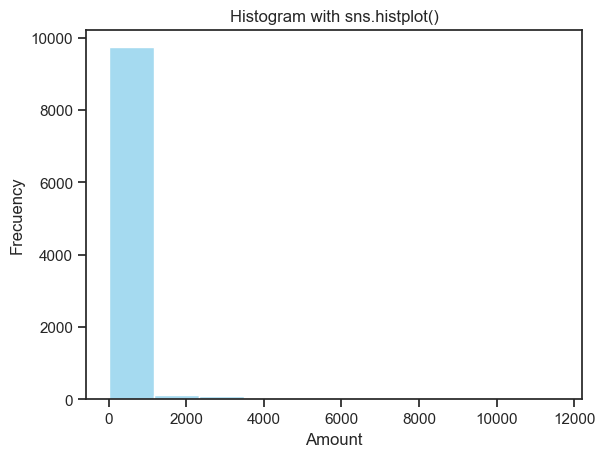

In [15]:
data=df['amount']
sns.histplot(data, bins=10, color='skyblue')
plt.title('Histogram with sns.histplot()')
plt.xlabel('Amount')
plt.ylabel('Frecuency')
plt.show()